# 解說
這一篇承襲20260324_code資料夾裡的 "OU_IDSM test-2D Spiral_betaSigmaConst" 這一篇。  
找到具體例子驗證:  
* $I_{DSM}$ 小 $\Rightarrow$ 圖好  
* $I_{DSM}$ 大 $\Rightarrow$ 圖差  
  
針對這個例題，我們將以一組同樣的beta, t以及**5組不同steps切割**，與其對應的t去做比較loss與$I_{DSM}$的結果

# Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sample_p0_mix(n_points=2500):
    theta = np.sqrt(np.random.rand(n_points)) * 6 * np.pi # 角度
    r = 1 * theta 
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    data = np.stack([x, y], axis=1) + np.random.randn(n_points, 2) * 0.1
    return data

In [3]:
# --- 定義五組實驗參數 ---
#beta_list = [1.0]
#target_constant = 10.0
#sigma = 5.0  # 保持固定

# 建立一個字典來存儲每一組對應的 T (時間終點)
#configs = {b: target_constant / b for b in beta_list}

# 原本的 mu_t, std_t 建議寫成函數，方便在訓練迴圈中調用
def get_diffused_sample(x0, t, beta, sigma):
    # t 可以是一個 tensor (batch_size, 1)
    mu_t = np.exp(-beta * t) * x0
    var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
    std_t = np.sqrt(var_t)
    eps = np.random.randn(*x0.shape)
    xt = mu_t + std_t * eps
    return xt, std_t, eps

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), 
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [5]:
def train(model, beta, sigma, T, steps, device):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    loss_his = []
    iDsm_his = []

    model.train() 
    for i in range(steps):
        x0_np = sample_p0_mix(n_points=2500)
        x0 = torch.tensor(x0_np, dtype=torch.float32).to(device)
        
        t = (torch.rand(x0.shape[0]) * T).to(device)
        
        t_view = t.view(-1, 1) 
        mu_t = torch.exp(-beta * t_view) * x0
        
        var_t = (sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t_view))
        std_t = torch.sqrt(var_t)
        
        eps = torch.randn_like(x0).to(device)
        xt = mu_t + std_t * eps
        
        optimizer.zero_grad()
        eps_pred = model(xt, t) # model(xt, t)
        
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            inner_product = torch.sum(eps_pred * (eps_pred - eps), dim=1, keepdim=True)
            i_dsm_batch = torch.mean(inner_product / sigma**2)

        loss_his.append(loss.item())
        iDsm_his.append(i_dsm_batch.item())
        
        if i % 100 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}, Idsm: {i_dsm_batch.item():.4f}")
            
    return loss_his, iDsm_his

device = torch.device("cpu")

In [6]:
@torch.no_grad()
def reverse_sample(model, n_samples, beta, sigma, T, dt):
    device = next(model.parameters()).device
    var_T = sigma**2 / (2 * beta)
    x = torch.randn(n_samples, 2).to(device) * np.sqrt(var_T)
    
    ts = np.arange(T, 0, -dt)
    for t_val in ts:
        t_tensor = torch.full((n_samples,), t_val).to(device)
        eps_pred = model(x, t_tensor)
        sigma_t = torch.sqrt((sigma**2 / (2 * beta)) * (1 - torch.exp(torch.tensor(-2 * beta * t_val))))
        score = -eps_pred / (sigma_t + 1e-5)
        
        drift = -beta * x - (sigma**2) * score
        noise = torch.randn_like(x) if t_val > dt else 0
        
        x = x - drift * dt + sigma * np.sqrt(dt) * noise
        
    return x

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 參數設定 ---
beta_fixed = 0.5
sigma_fixed = 2.0
T_fixed = 20.0  # 因為 beta * T = 10
total_steps = 5000
snapshot_steps = [500, 1000, 2000, 5000]

# 重新初始化模型
model = ScoreNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 儲存結果
history = {"loss": [], "idsm": [], "idsm2": []}
snapshots = {}

print(f"開始收斂實驗 (Fixed Beta={beta_fixed}, Sigma={sigma_fixed})...")

model.train()
for i in range(1, total_steps + 1):
    # 數據生成
    x0_np = sample_p0_mix(n_points=2500)
    x0 = torch.tensor(x0_np, dtype=torch.float32).to(device)
    t = (torch.rand(x0.shape[0]) * T_fixed).to(device)
    t_view = t.view(-1, 1) 
    
    mu_t = torch.exp(-beta_fixed * t_view) * x0
    var_t = (sigma_fixed**2 / (2*beta_fixed)) * (1 - torch.exp(-2*beta_fixed*t_view))
    std_t = torch.sqrt(var_t)
    eps = torch.randn_like(x0).to(device)
    xt = mu_t + std_t * eps
    
    # 訓練步
    optimizer.zero_grad()
    eps_pred = model(xt, t)
    loss = nn.MSELoss()(eps_pred, eps)
    loss.backward()
    optimizer.step()
    
    # 指標計算
    with torch.no_grad():
        inner_product = torch.sum(eps_pred * (eps_pred - eps), dim=1, keepdim=True)
        i_dsm_batch = torch.mean(inner_product / sigma_fixed**2).item()
        
        history["loss"].append(loss.item())
        history["idsm"].append(i_dsm_batch)
        history["idsm2"].append(abs(i_dsm_batch))

    # 到達 Snapshot 步數時，進行採樣
    if i in snapshot_steps:
        print(f"Step {i}: 正在採樣...")
        gen_samples = reverse_sample(
            model, n_samples=2500, beta=beta_fixed, sigma=sigma_fixed, 
            T=T_fixed, dt=T_fixed/2000
        )
        
        # 記錄當前的平均指標 (取最近 100 步的平均較能反映當前狀態)
        window = 100
        avg_idsm = np.mean(history["idsm"][-window:])
        avg_idsm2 = np.mean(history["idsm2"][-window:])
        
        snapshots[i] = {
            "data": gen_samples.cpu().numpy(),
            "idsm": avg_idsm,
            "idsm2": avg_idsm2
        }

print("實驗完成！")

開始收斂實驗 (Fixed Beta=0.5, Sigma=2.0)...
Step 500: 正在採樣...
Step 1000: 正在採樣...
Step 2000: 正在採樣...
Step 5000: 正在採樣...
實驗完成！


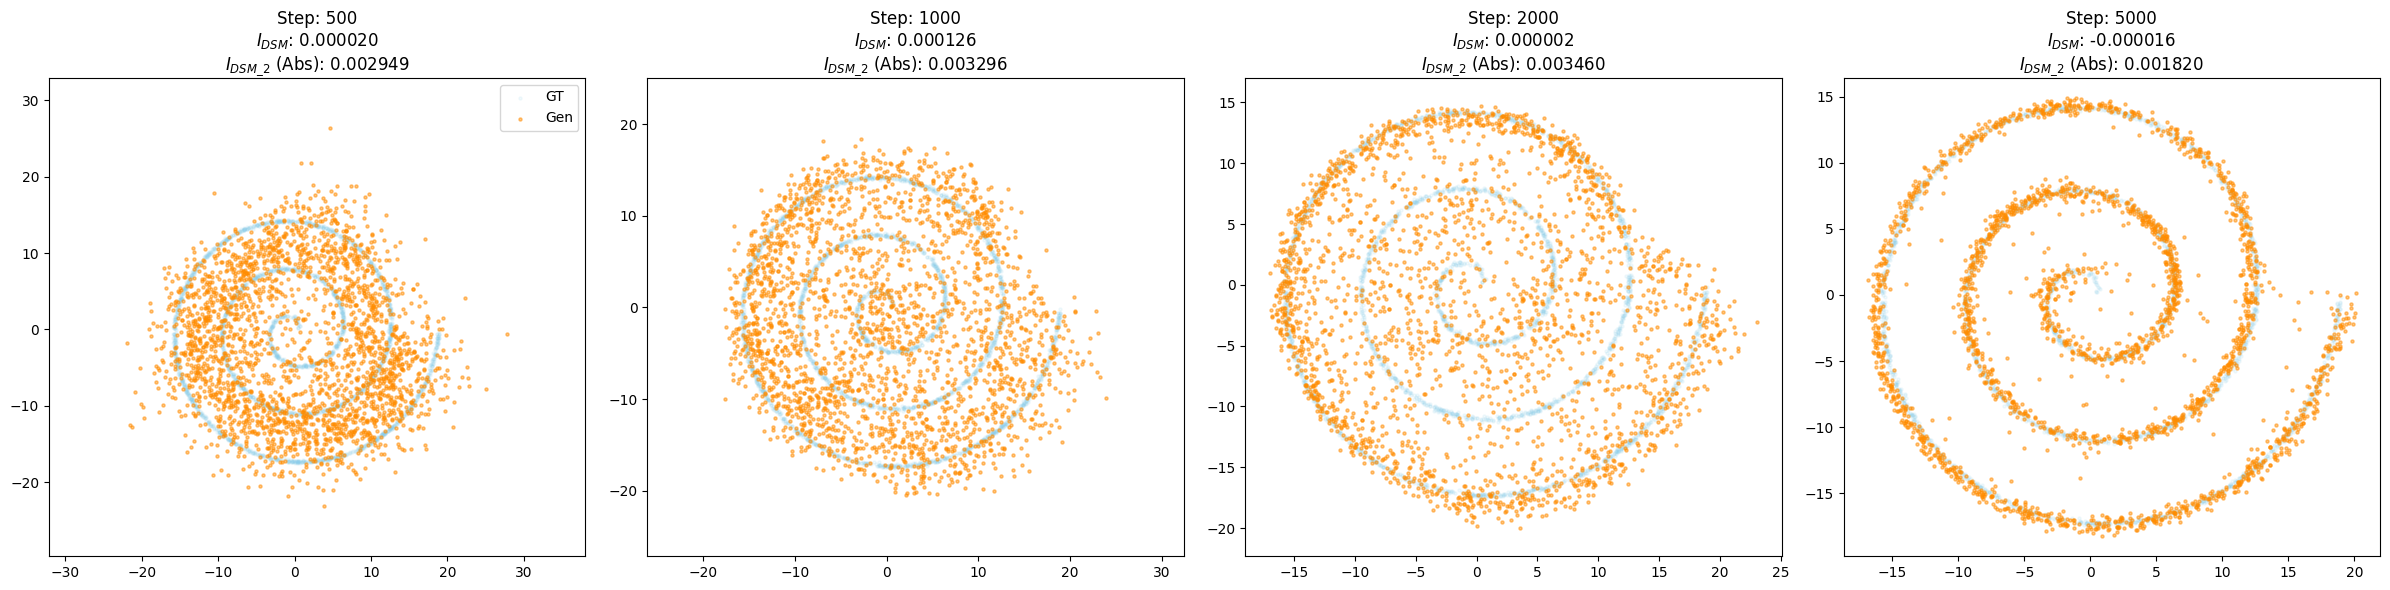

In [12]:
plt.figure(figsize=(24, 6))
gt_data = sample_p0_mix(n_points=2500)


#x_min, x_max = gt_data[:, 0].min() - 5, gt_data[:, 0].max() + 5
#y_min, y_max = gt_data[:, 1].min() - 5, gt_data[:, 1].max() + 5
for idx, step in enumerate(snapshot_steps):
    plt.subplot(1, 4, idx + 1)
    res = snapshots[step]
    gen = res["data"]
    
    plt.scatter(gt_data[:, 0], gt_data[:, 1], color='skyblue', s=5, alpha=0.1, label='GT')
    plt.scatter(gen[:, 0], gen[:, 1], color='darkorange', s=5, alpha=0.5, label='Gen')
    
    plt.xlim(-35, 32)
    plt.ylim(-25, 25)
    #plt.gca().set_aspect('equal', adjustable='box')
    # 在標題標註關鍵指標
    plt.title(f"Step: {step}\n$I_{{DSM}}$: {res['idsm']:.6f}\n$I_{{DSM\_2}}$ (Abs): {res['idsm2']:.6f}", fontsize=12)
    plt.axis('equal')
    if idx == 0: plt.legend()

plt.tight_layout()
plt.show()